# final10 — 보간포함 baseline

final7 구조를 그대로 유지하되, 데이터 구성만 변경한다.

- final7: 36개월 완전관측 법인만 사용
- final10: 36개월 완전관측 법인 + `중간랜덤누락_보간후보` 법인을 규칙 기반 보간 후 추가
- 변수 구조: final7과 동일하게 원본 금융 변수 기반 baseline
- 주의: 거래건수 계열, y 생성 변수, 보간여부 플래그는 모델 feature에서 제외한다.


## STEP 0. 라이브러리

In [17]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    precision_score,
    precision_recall_curve,
    confusion_matrix,
    accuracy_score,
)

try:
    from lightgbm import LGBMClassifier
except ImportError as e:
    raise ImportError("lightgbm이 설치되어 있어야 합니다. `pip install lightgbm` 후 다시 실행하세요.") from e

matplotlib.rcParams['font.family'] = 'Malgun Gothic'   # Mac: 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

EPS = 1e-6
EPS2 = 1e-9
RANDOM_STATE = 42
DATA_PATH = '36.csv'
NOTEBOOK_NAME = 'final10'

print(f'NOTEBOOK_NAME = {NOTEBOOK_NAME}')

NOTEBOOK_NAME = final10


## STEP 1. 데이터 로드 + 누락검정 기반 보간

In [18]:
import os
from scipy.stats import norm

# ============================================================
# final10 데이터 구성
# - 원본 전체 법인데이터.csv에서 누락검정 수행
# - 완전관측_정상 + 중간랜덤누락_보간후보만 사용
# - 보간 엔진은 기존 규칙 기반 구조를 유지
# - CSV 출력은 하지 않고 df로 바로 사용
# ============================================================

INPUT_PATH = 'iM_edu.csv'
PERIOD = ('2023-01', '2025-12')
ZERO_CNT_LABEL = '0건'
RUNS_ALPHA = 0.05
GAP_ALPHA = 0.01
APPLY_RANDOM_FILTER_TO_MID = True

# ------------------------------------------------------------
# 1. 보간 컬럼 분류 유틸
# ------------------------------------------------------------
def infer_decimals(s, max_sample=1000):
    """관측값의 소수 자릿수를 추정하여 보간 후 라운딩 자릿수로 사용."""
    vals = pd.to_numeric(s, errors='coerce').dropna().head(max_sample)
    if len(vals) == 0:
        return 0

    decs = []
    for v in vals:
        txt = str(v)
        if 'e' in txt.lower():
            txt = f'{float(v):.10f}'.rstrip('0').rstrip('.')
        if '.' in txt:
            decs.append(len(txt.split('.')[-1].rstrip('0')))
        else:
            decs.append(0)
    return int(max(decs)) if decs else 0


def classify_columns(df):
    """
    보간 규칙별 컬럼 분류.
    - locf: 범주형 상태 + 보유수 버킷
    - zero_cnt: 거래건수 버킷 → 결측 0건
    - zero_amt: 발생성 금액/실적/사용액 → 결측 0
    - cont: 잔액/한도 등 상태성 연속값 → 내부 선형보간 + ffill/bfill
    """
    id_cols = {'법인ID', '기준년월'}
    groups = {'locf': [], 'zero_cnt': [], 'zero_amt': [], 'cont': []}

    for c in df.columns:
        if c in id_cols:
            continue

        cs = str(c)

        # 거래건수 버킷은 결측 월에 거래 없음으로 처리
        if '거래건수' in cs:
            groups['zero_cnt'].append(c)
            continue

        # 범주형 상태 / 보유수 버킷
        if (
            cs in ['업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구']
            or '좌수' in cs
            or '개수' in cs
        ):
            groups['locf'].append(c)
            continue

        # 잔액/한도는 상태성 연속값
        if any(k in cs for k in ['잔액', '한도']):
            groups['cont'].append(c)
            continue

        # 금액/실적/사용액은 발생성 flow로 보고 결측 0
        if any(k in cs for k in ['금액', '실적', '사용액']):
            groups['zero_amt'].append(c)
            continue

        # 기타 object/category는 LOCF
        if not pd.api.types.is_numeric_dtype(df[c]):
            groups['locf'].append(c)
            continue

        # 기타 숫자형은 보수적으로 상태성 연속값 처리
        groups['cont'].append(c)

    return groups


# ------------------------------------------------------------
# 2. 누락검정 프로필 생성 유틸
# ------------------------------------------------------------
def make_obs_vector(corp_df, all_months):
    actual_months = set(corp_df['기준년월'])
    return [1 if m in actual_months else 0 for m in all_months]


def runs_test_binary(obs_vector):
    """
    H0: 관측(1)과 누락(0)은 랜덤하게 배열되어 있다.
    H1: 관측/누락이 군집되어 있다.
    단측검정: runs가 기대보다 유의하게 적은 방향.
    """
    x = np.array([int(v) for v in obs_vector])
    n1 = np.sum(x == 1)
    n0 = np.sum(x == 0)

    if n0 == 0 or n1 == 0:
        return {
            'runs': np.nan,
            'expected_runs': np.nan,
            'var_runs': np.nan,
            'z_runs': np.nan,
            'p_runs_lower': np.nan,
            'runs_result': '검정불가'
        }

    runs = 1 + np.sum(x[1:] != x[:-1])
    n = len(x)
    expected_runs = 1 + (2 * n1 * n0) / n
    var_runs = ((2 * n1 * n0) * (2 * n1 * n0 - n)) / (n**2 * (n - 1))

    if var_runs <= 0:
        return {
            'runs': runs,
            'expected_runs': expected_runs,
            'var_runs': var_runs,
            'z_runs': np.nan,
            'p_runs_lower': np.nan,
            'runs_result': '검정불가'
        }

    z = (runs - expected_runs) / np.sqrt(var_runs)
    p_lower = norm.cdf(z)
    result = '비랜덤_군집누락' if (p_lower < RUNS_ALPHA and z < 0) else '랜덤누락_가능'

    return {
        'runs': runs,
        'expected_runs': expected_runs,
        'var_runs': var_runs,
        'z_runs': z,
        'p_runs_lower': p_lower,
        'runs_result': result
    }


def build_corp_profile(df, all_months, q_miss):
    N_MONTHS = len(all_months)
    FIRST_MONTH = all_months[0]
    LAST_MONTH = all_months[-1]

    rows = []

    for corp_id, corp_df in df.groupby('법인ID'):
        obs_vector_list = make_obs_vector(corp_df, all_months)
        obs_vector = ''.join(map(str, obs_vector_list))

        month_cnt = sum(obs_vector_list)
        total_gap = N_MONTHS - month_cnt

        if month_cnt == 0:
            continue

        first_idx = obs_vector_list.index(1)
        last_idx = len(obs_vector_list) - 1 - obs_vector_list[::-1].index(1)

        first_month = all_months[first_idx]
        last_month = all_months[last_idx]
        leading_gap = first_idx
        trailing_gap = N_MONTHS - 1 - last_idx

        # 중간 누락 구간
        internal_gaps = []
        current_gap = 0
        for i in range(first_idx, last_idx + 1):
            if obs_vector_list[i] == 0:
                current_gap += 1
            else:
                if current_gap > 0:
                    internal_gaps.append(current_gap)
                current_gap = 0
        if current_gap > 0:
            internal_gaps.append(current_gap)

        max_internal_gap = max(internal_gaps, default=0)
        total_internal_gap = sum(internal_gaps)
        internal_gap_cnt = len(internal_gaps)

        # 전체 최대 연속 누락
        all_gaps = []
        current_gap = 0
        for v in obs_vector_list:
            if v == 0:
                current_gap += 1
            else:
                if current_gap > 0:
                    all_gaps.append(current_gap)
                current_gap = 0
        if current_gap > 0:
            all_gaps.append(current_gap)

        max_gap = max(all_gaps, default=0)
        gap_cnt = len(all_gaps)

        runs_info = runs_test_binary(obs_vector_list)

        rows.append({
            '법인ID': corp_id,
            'obs_vector': obs_vector,
            'month_cnt': month_cnt,
            'total_gap': total_gap,
            'gap_cnt': gap_cnt,
            'max_gap': max_gap,
            'first_month': first_month,
            'last_month': last_month,
            'leading_gap': leading_gap,
            'trailing_gap': trailing_gap,
            'internal_gap_cnt': internal_gap_cnt,
            'max_internal_gap': max_internal_gap,
            'total_internal_gap': total_internal_gap,
            **runs_info
        })

    prof = pd.DataFrame(rows)

    def classify_life_type(row):
        first = row['first_month']
        last = row['last_month']
        max_internal_gap = row['max_internal_gap']

        if first == FIRST_MONTH and last == LAST_MONTH:
            return '완전관측형' if max_internal_gap == 0 else '중간누락형'
        elif first > FIRST_MONTH and last == LAST_MONTH:
            return '신규유입후보'
        elif first == FIRST_MONTH and last < LAST_MONTH:
            return '중도종료후보'
        elif first > FIRST_MONTH and last < LAST_MONTH:
            return '불완전관측형'
        return '기타'

    prof['life_type'] = prof.apply(classify_life_type, axis=1)

    prof['p_leading_gap'] = q_miss ** prof['leading_gap']
    prof['p_trailing_gap'] = q_miss ** prof['trailing_gap']
    prof.loc[prof['leading_gap'] == 0, 'p_leading_gap'] = 1
    prof.loc[prof['trailing_gap'] == 0, 'p_trailing_gap'] = 1

    prof['missing_randomness'] = np.where(
        prof['runs_result'] == '비랜덤_군집누락',
        '비랜덤_군집누락',
        '랜덤누락_가능'
    )

    def final_status(row):
        lt = row['life_type']
        lead_sig = row['p_leading_gap'] < GAP_ALPHA
        trail_sig = row['p_trailing_gap'] < GAP_ALPHA
        internal_nonrandom = row['runs_result'] == '비랜덤_군집누락'

        if lt == '완전관측형':
            return '완전관측_정상'

        if lt == '신규유입후보':
            return '신규유입' if lead_sig else '초반단기누락_보간후보'

        if lt == '중도종료후보':
            return '중도종료_이탈후보' if trail_sig else '후반단기누락_보간후보'

        if lt == '중간누락형':
            return '중간군집누락_비활동후복귀후보' if internal_nonrandom else '중간랜덤누락_보간후보'

        if lt == '불완전관측형':
            if lead_sig and trail_sig:
                return '신규유입후_중도종료후보'
            elif lead_sig and not trail_sig:
                return '신규유입후_후반단기누락보간후보'
            elif not lead_sig and trail_sig:
                return '초반단기누락보간후_중도종료후보'
            else:
                return '초반후반_단기누락보간후보'

        return '기타'

    prof['final_status'] = prof.apply(final_status, axis=1)
    return prof


# ------------------------------------------------------------
# 3. 보간 엔진
# ------------------------------------------------------------
def impute_corp(g, all_months, groups, dec_map):
    """단일 법인 g를 36개월 풀패널로 재확장 + 규칙별 보간. frame 반환."""
    base = pd.DataFrame({'기준년월': all_months})
    merged = base.merge(g, on='기준년월', how='left')
    merged['보간여부'] = merged['법인ID'].isna().astype(int)
    merged['법인ID'] = g['법인ID'].iloc[0]

    # 범주형 상태 + 보유수 버킷: LOCF → NOCB 폴백
    for c in groups['locf']:
        if c in merged.columns:
            merged[c] = merged[c].ffill().bfill()

    # 거래건수 버킷: "0건"
    for c in groups['zero_cnt']:
        if c in merged.columns:
            merged[c] = merged[c].fillna(ZERO_CNT_LABEL)

    # 발생성 금액: 0
    for c in groups['zero_amt']:
        if c in merged.columns:
            merged[c] = merged[c].fillna(0)

    # 연속형 상태(잔액/한도): 내부=선형보간, 후반=LOCF, 초반=NOCB → 재라운딩
    for c in groups['cont']:
        if c in merged.columns:
            s = pd.to_numeric(merged[c], errors='coerce')
            s = s.interpolate(method='linear', limit_area='inside')
            s = s.ffill().bfill()
            merged[c] = s.round(dec_map.get(c, 0))

    return merged


# ------------------------------------------------------------
# 4. 실행 함수
# ------------------------------------------------------------
def main(input_path=INPUT_PATH):
    df_raw = pd.read_csv(input_path)
    df_raw['기준년월'] = (
        df_raw['기준년월']
        .astype(str)
        .str.replace('-', '', regex=False)
        .str.replace('.', '', regex=False)
        .str.slice(0, 6)
        .astype(int)
    )

    months = pd.period_range(PERIOD[0], PERIOD[1], freq='M')
    all_months = [int(m.strftime('%Y%m')) for m in months]
    N = len(all_months)

    df_raw = (
        df_raw[df_raw['기준년월'].isin(all_months)]
        .drop_duplicates(['법인ID', '기준년월'], keep='last')
        .sort_values(['법인ID', '기준년월'])
        .reset_index(drop=True)
    )

    n_corp = df_raw['법인ID'].nunique()
    q_miss = 1 - len(df_raw) / (n_corp * N)
    print(f'법인수={n_corp:,}  관측치={len(df_raw):,}  q_miss={q_miss:.4f}')

    groups = classify_columns(df_raw)
    dec_map = {c: infer_decimals(df_raw[c]) for c in groups['cont']}
    print('분류: LOCF=%d, 0건=%d, 0금액=%d, 선형=%d'
          % (len(groups['locf']), len(groups['zero_cnt']),
             len(groups['zero_amt']), len(groups['cont'])))

    prof = build_corp_profile(df_raw, all_months, q_miss)
    print('\n[최종 상태 분포]')
    print(prof['final_status'].value_counts())

    # --- 그룹 선정 ---
    full_ids = prof.loc[prof['final_status'] == '완전관측_정상', '법인ID']

    # 기존 엔진 코드의 중간단기명과 현재 누락검정명의 중간랜덤명을 모두 허용
    mid_mask = prof['final_status'].isin(['중간랜덤누락_보간후보', '중간단기누락_보간후보'])
    if APPLY_RANDOM_FILTER_TO_MID and 'missing_randomness' in prof.columns:
        mid_mask &= prof['missing_randomness'] == '랜덤누락_가능'
    mid_ids = prof.loc[mid_mask, '법인ID']

    # 후반단기 후보는 참고용으로만 계산하고 final10에는 포함하지 않음
    late_ids = prof.loc[prof['final_status'] == '후반단기누락_보간후보', '법인ID']
    print(f'완전관측={len(full_ids):,}  중간랜덤={len(mid_ids):,}  후반단기={len(late_ids):,} (final10에는 후반단기 제외)')

    out_cols = list(df_raw.columns) + ['보간여부']

    # 1) 완전관측_정상: 보간 없음
    full = df_raw[df_raw['법인ID'].isin(set(full_ids))].copy()
    full['보간여부'] = 0
    full = full[out_cols].sort_values(['법인ID', '기준년월'])

    # 2) 중간랜덤누락_보간후보: 보간 후 추가
    def build_group(ids):
        ids = set(ids)
        if not ids:
            return pd.DataFrame(columns=out_cols), 0

        sub = df_raw[df_raw['법인ID'].isin(ids)]
        parts = [
            impute_corp(g, all_months, groups, dec_map)
            for _, g in sub.groupby('법인ID', sort=False)
        ]
        res = pd.concat(parts, ignore_index=True)[out_cols]
        res = res.sort_values(['법인ID', '기준년월'])
        return res, int(res['보간여부'].sum())

    mid, n_mid = build_group(mid_ids)

    # final10 = 완전관측 + 중간랜덤누락 보간후보
    df_final10 = pd.concat([full, mid], ignore_index=True)
    df_final10 = df_final10.sort_values(['법인ID', '기준년월']).reset_index(drop=True)

    print('\n[final10 데이터 구성]')
    print('완전관측 row:', len(full))
    print('중간랜덤 보간후 row:', len(mid))
    print('보간으로 생성된 row:', n_mid)
    print('최종 df shape:', df_final10.shape)
    print('최종 법인 수:', df_final10['법인ID'].nunique())
    print('기간:', df_final10['기준년월'].min(), '~', df_final10['기준년월'].max())

    return df_final10, prof, groups


df, corp_profile, impute_groups = main(INPUT_PATH)


법인수=15,473  관측치=365,988  q_miss=0.3430
분류: LOCF=27, 0건=8, 0금액=12, 선형=21

[최종 상태 분포]
final_status
중도종료_이탈후보           3592
신규유입                3397
완전관측_정상             3372
중간랜덤누락_보간후보         2351
후반단기누락_보간후보          703
초반단기누락_보간후보          495
신규유입후_중도종료후보         465
중간군집누락_비활동후복귀후보      384
신규유입후_후반단기누락보간후보     369
초반단기누락보간후_중도종료후보     262
초반후반_단기누락보간후보         83
Name: count, dtype: int64
완전관측=3,372  중간랜덤=2,351  후반단기=703 (final10에는 후반단기 제외)

[final10 데이터 구성]
완전관측 row: 121392
중간랜덤 보간후 row: 84636
보간으로 생성된 row: 5077
최종 df shape: (206028, 71)
최종 법인 수: 5723
기간: 202301 ~ 202512


## STEP 2. 전처리 (수치화 + 결측 처리만)

In [19]:
# ── 2-1. 구간 문자열(좌수/거래건수) → 수치 ──
def parse_count_str(s):
    if pd.isna(s) or str(s) in ['', '-']: return 0
    s = str(s)
    e = re.match(r'^(\d+)[개건]$', s)
    if e: return int(e.group(1))
    b = re.match(r'^(\d+)[개건]초과\s*(\d+)[개건]이하$', s)
    if b: return int(b.group(1)) + 1
    o = re.match(r'^(\d+)[개건]\s*초과$', s)
    if o: return int(o.group(1)) + 1
    return 0
for c in [col for col in df.columns if '좌수' in col or '거래건수' in col or '개수' in col]:
    df[c + '_num'] = df[c].apply(parse_count_str)

# ── 2-2. 결측치 처리 ──
df['지역_결측_여부'] = df['사업장_시도'].isna().astype(int)
df['사업장_시도']   = df['사업장_시도'].fillna('Unknown')
df['사업장_시군구'] = df['사업장_시군구'].fillna('Unknown')
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(0)
print(f"전처리 완료 | 잔여 결측: {df.isnull().sum().sum()}")


전처리 완료 | 잔여 결측: 0


## STEP 3. 타겟 변수(y) 생성 — 논문 정의 (기존과 동일)

베이스라인 비교를 위해 타겟은 그대로 유지한다.
거래빈도 변화율 ≤ -30% **또는** 거래 규칙성(CV) > 평균 → 부분 이탈(1).


In [20]:
# ============================================================
# STEP 3. 타겟 변수 생성 + 1개월 SHIFT 타깃 생성
# - 기존 y_current: 해당 월 거래활동성 약화 여부
# - y_next1: 다음 월 거래활동성 약화 여부
# - 모델 학습용 y는 y_next1로 덮어씀
# ============================================================

# 논문 Frequency 지표 / 거래활동성 약화 proxy 라벨 생성 재료
freq_num_cols = [
    '창구거래건수_num', '인터넷뱅킹거래건수_num', '스마트뱅킹거래건수_num',
    '폰뱅킹거래건수_num', 'ATM거래건수_num', '자동이체거래건수_num'
]

missing_freq_cols = [c for c in freq_num_cols if c not in df.columns]
if missing_freq_cols:
    raise ValueError(f'거래건수 수치화 컬럼이 없습니다: {missing_freq_cols}')

df = df.sort_values(['법인ID', '기준년월']).copy().reset_index(drop=True)
df['총거래건수'] = df[freq_num_cols].sum(axis=1)

# 조건1: 거래빈도 이동 구간 변화율
# 주의: 기존 코드와 동일하게 현재 row 직전 구간을 사용한다.
# 즉 M_freq_t는 t월 row에서 과거 6개월 흐름을 요약한 값이다.
def compute_rolling_change(series, past=3, recent=3):
    n = len(series)
    M = np.full(n, np.nan)
    for i in range(past + recent, n):
        ps = series.iloc[i-past-recent : i-recent].sum()   # 이전 3개월
        rs = series.iloc[i-recent : i].sum()               # 최근 3개월
        M[i] = (rs - ps) / (ps + EPS)
    return M

df['M_freq'] = df.groupby('법인ID')['총거래건수'].transform(
    lambda x: compute_rolling_change(x.reset_index(drop=True))
)

# 조건2: 거래 규칙성 / 변동계수
def rolling_cv(series, window=6):
    m = series.rolling(window, min_periods=3).mean()
    sd = series.rolling(window, min_periods=3).std()
    return sd / (m + EPS)

df['freq_CV'] = df.groupby('법인ID')['총거래건수'].transform(
    lambda x: rolling_cv(x.reset_index(drop=True)).values
)

# warm-up 행은 y_current 계산 불가
# y_current = 해당 월 기준 거래활동성 약화 여부
df['y_available'] = df['M_freq'].notna() & df['freq_CV'].notna()
CV_BASELINE = df.loc[df['y_available'], 'freq_CV'].mean()

df['y_current'] = np.nan
df.loc[df['y_available'], 'y_current'] = (
    (df.loc[df['y_available'], 'M_freq'] <= -0.30) |
    (df.loc[df['y_available'], 'freq_CV'] > CV_BASELINE)
).astype(int)

# ------------------------------------------------------------
# 1개월 선행 타깃 생성
# X_t -> y_next1 = y_current_{t+1}
# ------------------------------------------------------------
df['y_next1'] = df.groupby('법인ID')['y_current'].shift(-1)
df['target_기준년월'] = df.groupby('법인ID')['기준년월'].shift(-1)

# 모델 학습용 행:
# - 현재월 피처가 안정적으로 계산 가능한 행(y_available=True)
# - 다음월 y가 존재하는 행(y_next1 notna)
model_mask = df['y_available'] & df['y_next1'].notna()
df_model = df.loc[model_mask].copy().reset_index(drop=True)

# 기존 downstream 코드와 호환되도록 y 컬럼명을 유지하되, 내용은 y_next1로 교체
# 즉 이후 모든 모델의 target_col='y'는 실제로 다음월 거래활동성 약화 여부를 의미한다.
df_model['y'] = df_model['y_next1'].astype(int)
df_model['y_current'] = df_model['y_current'].astype(int)

print('=' * 80)
print('Y 1개월 SHIFT 타깃 생성 완료')
print('=' * 80)
print('전체 df shape:', df.shape)
print('모델링 df_model shape:', df_model.shape)
print('warm-up 행 수:', int((~df['y_available']).sum()))
print('다음월 y 없음으로 제외된 행 수:', int((df['y_available'] & df['y_next1'].isna()).sum()))
print('모델 구조: X_t -> y_next1 = y_{t+1}')
print('X 기준월 범위:', df_model['기준년월'].min(), '~', df_model['기준년월'].max())
print('Target 기준월 범위:', df_model['target_기준년월'].min(), '~', df_model['target_기준년월'].max())

print('\n[y_next1 분포: 모델 학습 target y]')
print(df_model['y'].value_counts())
print(df_model['y'].value_counts(normalize=True))

print('\n[샘플: X 기준월 -> target 기준월]')
display(df_model[['법인ID', '기준년월', 'target_기준년월', 'y_current', 'y_next1', 'y']].head(10))


Y 1개월 SHIFT 타깃 생성 완료
전체 df shape: (206028, 108)
모델링 df_model shape: (165967, 109)
warm-up 행 수: 34338
다음월 y 없음으로 제외된 행 수: 5723
모델 구조: X_t -> y_next1 = y_{t+1}
X 기준월 범위: 202307 ~ 202511
Target 기준월 범위: 202308.0 ~ 202512.0

[y_next1 분포: 모델 학습 target y]
y
0    101695
1     64272
Name: count, dtype: int64
y
0    0.612742
1    0.387258
Name: proportion, dtype: float64

[샘플: X 기준월 -> target 기준월]


,법인ID,기준년월,target_기준년월,y_current,y_next1,y
0,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202307,202308.0,0,0.0,0
1,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202308,202309.0,0,1.0,1
2,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202309,202310.0,1,1.0,1
3,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202310,202311.0,1,1.0,1
4,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202311,202312.0,1,1.0,1
5,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202312,202401.0,1,1.0,1
6,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202401,202402.0,1,1.0,1
7,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202402,202403.0,1,1.0,1
8,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202403,202404.0,1,1.0,1
9,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,202404,202405.0,1,1.0,1


---
# PART 2. 업종별 모델링 / 통합모델 / 앙상블

- 모델링 기준 데이터: `df_model` = y가 정의 가능한 30개월
- 대상 업종: 제조업, 도매 및 소매업, 건설업, 부동산업
- 모든 메인 모델에서 거래건수 계열 feature 제거
- 범주형: OneHotEncoding
- 수치형: train 기준 clipping + log1p
- 피처선택: train 기준 corr pruning


In [21]:
# ============================================================
# PART 2 준비: top4 업종 모델링용 데이터 생성
# ============================================================

TOP4_INDS = ['제조업', '도매 및 소매업', '건설업', '부동산업']

# df_model = y_available=True인 30개월 모델링 데이터
# 모델링/라벨 EDA/Feature Importance/SHAP은 df_model 기준으로 수행한다.
dfx = (
    df_model[df_model['업종_대분류'].isin(TOP4_INDS)]
    .sort_values(['법인ID', '기준년월'])
    .reset_index(drop=True)
    .copy()
)

print('=' * 70)
print('PART 2 시작: top4 업종 모델링 데이터')
print('=' * 70)
print('dfx shape:', dfx.shape)
print('법인 수:', dfx['법인ID'].nunique())
print('기간:', dfx['기준년월'].min(), '~', dfx['기준년월'].max())
print('전체 y=1 비율: %.2f%%' % (dfx['y'].mean() * 100))
print('\n업종별 행 수')
display(dfx['업종_대분류'].value_counts().to_frame('row_count'))

PART 2 시작: top4 업종 모델링 데이터
dfx shape: (130703, 109)
법인 수: 4507
기간: 202307 ~ 202511
전체 y=1 비율: 39.12%

업종별 행 수


,row_count
업종_대분류,
제조업,56347
도매 및 소매업,32045
건설업,27492
부동산업,14819


## 2-1. 0비율 처리

100% 0 변수는 제거하고, 0 비율이 85% 이상 100% 미만인 수치형 변수는 `zero/nonzero` 범주형 변수로 변환한다.

In [22]:
PROTECTED_COLS = ['법인ID','기준년월','기준년월_dt','y','y_available','M_freq','freq_CV','총거래건수']

# 5-1. 100% 0 변수 제거
zero_ratio = (dfx.select_dtypes(include=np.number)==0).mean().sort_values(ascending=False)
print('[0비율 상위 15]'); print(zero_ratio.head(15).round(3).to_string())
zero_100_cols = [c for c in zero_ratio[zero_ratio>=1.0].index if c not in PROTECTED_COLS]
print('\n100% 0 제거:', len(zero_100_cols)); print(zero_100_cols[:30])
dfx = dfx.drop(columns=zero_100_cols, errors='ignore')
print('after 100% zero drop:', dfx.shape)

# 5-2. 0비율 85%↑ <100% → zero/nonzero 범주형
HIGH_ZERO_THRESHOLD = 0.85
zr2 = (dfx.select_dtypes(include=np.number)==0).mean().sort_values(ascending=False)
high_zero_cols = [c for c in zr2[(zr2>=HIGH_ZERO_THRESHOLD)&(zr2<1.0)].index if c not in PROTECTED_COLS]
print(f'\n0비율 {HIGH_ZERO_THRESHOLD:.0%}↑ 변수:', len(high_zero_cols)); print(high_zero_cols[:30])
high_zero_cat_cols = []
for c in high_zero_cols:
    nc = f'{c}_zero_cat'
    dfx[nc] = np.where(dfx[c].fillna(0)==0, 'zero', 'nonzero')
    high_zero_cat_cols.append(nc)
HIGH_ZERO_NUMERIC_DROP_COLS = high_zero_cols
print('생성 zero_cat:', high_zero_cat_cols[:30])

[0비율 상위 15]
시설_주택자금대출좌수_num        1.000
운전_주택자금대출좌수_num        1.000
시설_주택자금대출잔액            1.000
운전_주택자금대출잔액            1.000
운전_당좌대출잔액              0.993
운전_외상매출채권담보대출잔액        0.985
운전_당좌대출좌수_num          0.983
수익증권잔액                 0.982
운전_무역금융잔액              0.981
시설_에너지절약시설대출잔액         0.979
운전_외상매출채권담보대출좌수_num    0.977
시설_에너지절약시설대출좌수_num     0.977
운전_무역금융좌수_num          0.976
수익증권좌수_num             0.975
보간여부                   0.974

100% 0 제거: 0
[]
after 100% zero drop: (130703, 109)

0비율 85%↑ 변수: 35
['시설_주택자금대출좌수_num', '운전_주택자금대출좌수_num', '시설_주택자금대출잔액', '운전_주택자금대출잔액', '운전_당좌대출잔액', '운전_외상매출채권담보대출잔액', '운전_당좌대출좌수_num', '수익증권잔액', '운전_무역금융잔액', '시설_에너지절약시설대출잔액', '운전_외상매출채권담보대출좌수_num', '시설_에너지절약시설대출좌수_num', '운전_무역금융좌수_num', '수익증권좌수_num', '보간여부', '운전_할인어음잔액', '외환_수출실적금액', '외환_수출실적거래건수_num', '운전_기업구매자금대출잔액', '체크카드사용금액', '외환_수입실적거래건수_num', '지역_결측_여부', '외환_수입실적금액', '운전_기업구매자금대출좌수_num', '운전_할인어음좌수_num', '시설_기타시설자금대출잔액', '적립식예금잔액', '시설_기타시설자금대출좌수_num', '거치식예금잔액', '운전_기타운전자금대출잔액']
생성 zero

## 2-2. Feature set 구성

거래건수 계열, 라벨 생성 변수, high-zero 원본 수치형 변수를 feature에서 제거한다.

In [23]:
# ============================================================
# Feature set 구성
# - y/라벨 후보/라벨 파생 변수 완전 제거
# - 거래건수 계열은 y 생성 직접 재료이므로 모든 메인 모델에서 제거
# - 보간여부 플래그는 모델 feature에서 제외
# - 거래금액 계열은 직접 재료가 아니므로 유지
# - high-zero 원본 수치형 변수는 제거하고 zero/nonzero 범주형만 사용
# ============================================================

FORBIDDEN_EXACT = [
    '법인ID', '기준년월', '기준년월_dt',
    'y', 'y_old', 'y_v2', 'y_v3', 'y_available', 'y_reason',
    'M_freq', 'freq_CV', '총거래건수',
    '보간여부', 'is_imputed_row', 'impute_target_corp',
    '창구거래건수_num', '인터넷뱅킹거래건수_num', '스마트뱅킹거래건수_num',
    '폰뱅킹거래건수_num', 'ATM거래건수_num', '자동이체거래건수_num',
    '창구거래건수', '인터넷뱅킹거래건수', '스마트뱅킹거래건수',
    '폰뱅킹거래건수', 'ATM거래건수', '자동이체거래건수'
]

COUNT_LEAK_KW = [
    '거래건수', '총거래건수', 'M_freq', 'freq_CV', 'freq', 'Frequency'
]

LABEL_LEAK_KW = [
    'label', 'target'
]

def is_forbidden_feature(c):
    """모델 feature에 들어가면 안 되는 컬럼 판별."""
    c = str(c)
    cl = c.lower()

    # y, y_old, y_v2_zero_cat, y_v3_zero_cat 등 전부 제거
    if c in FORBIDDEN_EXACT:
        return True
    if c.startswith('y'):
        return True

    # 거래건수/freq 계열은 y 생성 직접 재료라 제거
    if any(k in c for k in COUNT_LEAK_KW):
        return True

    # 일반적인 라벨/타겟 계열 제거
    if any(k in cl for k in LABEL_LEAK_KW):
        return True

    return False

forbidden_cols = [c for c in dfx.columns if is_forbidden_feature(c)]

print('=' * 70)
print('Feature exclusion 점검')
print('=' * 70)
print('누수/라벨/거래건수/보간플래그 제거 후보 수:', len(forbidden_cols))
print(forbidden_cols[:80])

# final10은 final7과 동일한 원본 변수 baseline이다.
# 단, y 후보/거래건수 계열/보간플래그와 high-zero 원본 수치형은 제외한다.
SUM_INGREDIENT_COLS = []

EXCLUDE_COLS = set(
    forbidden_cols
    + list(HIGH_ZERO_NUMERIC_DROP_COLS)
    + SUM_INGREDIENT_COLS
)

print('high-zero 원본 수치형 제거 수:', len(HIGH_ZERO_NUMERIC_DROP_COLS))
print('총 EXCLUDE 수:', len(EXCLUDE_COLS))

# 범주형 후보 + high-zero zero_cat
BASE_CAT_COLS = ['업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구']

high_zero_cat_cols_raw = list(high_zero_cat_cols)
high_zero_cat_cols = [
    c for c in high_zero_cat_cols_raw
    if c in dfx.columns and not is_forbidden_feature(c)
]

CAT_COLS_CANDIDATE = [
    c for c in BASE_CAT_COLS + high_zero_cat_cols
    if c in dfx.columns
]

CAT_FEAT_ALL = [
    c for c in CAT_COLS_CANDIDATE
    if c not in EXCLUDE_COLS and not is_forbidden_feature(c)
]

NUM_FEAT_ALL = [
    c for c in dfx.columns
    if c not in EXCLUDE_COLS
    and c not in CAT_FEAT_ALL
    and not is_forbidden_feature(c)
    and pd.api.types.is_numeric_dtype(dfx[c])
]

# 결측/inf 처리
for c in CAT_FEAT_ALL:
    dfx[c] = dfx[c].fillna('Unknown').astype(str)

if len(NUM_FEAT_ALL) > 0:
    dfx[NUM_FEAT_ALL] = (
        dfx[NUM_FEAT_ALL]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

print('\n최종 피처 수')
print('NUM_FEAT:', len(NUM_FEAT_ALL))
print('CAT_FEAT:', len(CAT_FEAT_ALL))
print('CAT_FEAT 목록:', CAT_FEAT_ALL[:40])

# 최종 누수 검증
leak = [c for c in NUM_FEAT_ALL + CAT_FEAT_ALL if is_forbidden_feature(c)]
assert len(leak) == 0, f'누수 컬럼이 feature에 남아 있습니다: {leak}'

print('최종 누수 검증 OK')
print('제거된 high-zero zero_cat 예시:', [c for c in high_zero_cat_cols_raw if is_forbidden_feature(c)][:20])


Feature exclusion 점검
누수/라벨/거래건수/보간플래그 제거 후보 수: 30
['기준년월', '법인ID', '외환_수출실적거래건수', '외환_수입실적거래건수', '창구거래건수', '인터넷뱅킹거래건수', '스마트뱅킹거래건수', '폰뱅킹거래건수', 'ATM거래건수', '자동이체거래건수', '보간여부', '외환_수출실적거래건수_num', '외환_수입실적거래건수_num', '창구거래건수_num', '인터넷뱅킹거래건수_num', '스마트뱅킹거래건수_num', '폰뱅킹거래건수_num', 'ATM거래건수_num', '자동이체거래건수_num', '총거래건수', 'M_freq', 'freq_CV', 'y_available', 'y_current', 'y_next1', 'target_기준년월', 'y', '외환_수출실적거래건수_num_zero_cat', '외환_수입실적거래건수_num_zero_cat', '폰뱅킹거래건수_num_zero_cat']
high-zero 원본 수치형 제거 수: 35
총 EXCLUDE 수: 61

최종 피처 수
NUM_FEAT: 24
CAT_FEAT: 36
CAT_FEAT 목록: ['업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구', '시설_주택자금대출좌수_num_zero_cat', '운전_주택자금대출좌수_num_zero_cat', '시설_주택자금대출잔액_zero_cat', '운전_주택자금대출잔액_zero_cat', '운전_당좌대출잔액_zero_cat', '운전_외상매출채권담보대출잔액_zero_cat', '운전_당좌대출좌수_num_zero_cat', '수익증권잔액_zero_cat', '운전_무역금융잔액_zero_cat', '시설_에너지절약시설대출잔액_zero_cat', '운전_외상매출채권담보대출좌수_num_zero_cat', '시설_에너지절약시설대출좌수_num_zero_cat', '운전_무역금융좌수_num_zero_cat', '수익증권좌수_num_zero_cat', '보간여부_zero_cat', '운전_할인어음잔액_zero

## 단계2 — train/valid/test 시간 분할

In [24]:
# ============================================================
# 시간 기준 train / valid / test split
# - test: 2025.10~2025.12
# - valid: test 제외 후 가장 최근 3개월
# - train: 나머지 과거 기간
# ============================================================

dfx = dfx.copy()
dfx['기준년월'] = (
    dfx['기준년월']
    .astype(str)
    .str.replace('-', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.slice(0, 6)
    .astype(int)
)

test_months_p2 = [202510, 202511, 202512]
_test_mask = dfx['기준년월'].isin(test_months_p2)
_train_valid_mask = ~_test_mask
valid_months = sorted(dfx.loc[_train_valid_mask, '기준년월'].unique())[-3:]

df_train = dfx[_train_valid_mask & ~dfx['기준년월'].isin(valid_months)].copy()
df_valid = dfx[_train_valid_mask &  dfx['기준년월'].isin(valid_months)].copy()
df_test  = dfx[_test_mask].copy()

print('[Split month]')
print('Train months:', df_train['기준년월'].min(), '~', df_train['기준년월'].max())
print('Valid months:', sorted(df_valid['기준년월'].unique()))
print('Test months :', sorted(df_test['기준년월'].unique()))

print('\n[Split size]')
print(
    f'Train {len(df_train):,} '
    f'(위험군 {df_train["y"].mean()*100:.1f}%) | '
    f'Valid {len(df_valid):,} '
    f'(위험군 {df_valid["y"].mean()*100:.1f}%) | '
    f'Test {len(df_test):,} '
    f'(위험군 {df_test["y"].mean()*100:.1f}%)'
)

print('\n[업종별 split row 수]')
split_ind_cnt = pd.DataFrame({
    'train': df_train['업종_대분류'].value_counts(),
    'valid': df_valid['업종_대분류'].value_counts(),
    'test': df_test['업종_대분류'].value_counts()
}).fillna(0).astype(int)
display(split_ind_cnt)

# sanity check
assert len(df_train) > 0, 'df_train이 비어 있습니다.'
assert len(df_valid) > 0, 'df_valid가 비어 있습니다.'
assert len(df_test) > 0, 'df_test가 비어 있습니다. 기준년월 타입 또는 test_months를 확인하세요.'
assert set(df_train['기준년월']).isdisjoint(set(df_valid['기준년월']))
assert set(df_train['기준년월']).isdisjoint(set(df_test['기준년월']))
assert set(df_valid['기준년월']).isdisjoint(set(df_test['기준년월']))
print('\nsplit sanity check 통과')


[Split month]
Train months: 202307 ~ 202506
Valid months: [202507, 202508, 202509]
Test months : [202510, 202511]

[Split size]
Train 108,168 (위험군 38.9%) | Valid 13,521 (위험군 39.6%) | Test 9,014 (위험군 40.7%)

[업종별 split row 수]


,train,valid,test
업종_대분류,,,
제조업,46632,5829,3886
도매 및 소매업,26520,3315,2210
건설업,22752,2844,1896
부동산업,12264,1533,1022



split sanity check 통과


## 3-1. 전처리 함수

train 기준 clipping/log1p, corr pruning, OneHotEncoder 기반 pipeline을 정의한다.

In [25]:
# ============================================================
# 전처리/모델링 유틸
# - train 기준 clipping/log1p
# - train 기준 corr pruning: y를 사용하지 않고 X끼리의 중복성만 제거
# - OneHotEncoder + LightGBM pipeline
# ============================================================

LOW_Q, HIGH_Q = 0.005, 0.995
CORR_THRESHOLD = 0.90

LOG_KW = [
    '금액', '잔액', '실적', '사용액', '한도',
    '총예금', '총여신', '총투자', '총거래',
    '비대면거래금액', '창구거래금액', '자동이체금액'
]

NO_LOG_KW = [
    '비중', '비율', '전환율', 'CV', 'pct', 'diff',
    '감소여부', '연속하락기간', 'accel', 'HHI', '엔트로피',
    '_X_', '_BUT_'
]

def is_log_target(col):
    col = str(col)
    has_log_kw = any(k in col for k in LOG_KW)
    has_no_log_kw = any(k in col for k in NO_LOG_KW)
    return has_log_kw and not has_no_log_kw

def fit_clip(Xtr, cols):
    bounds = {}
    for c in cols:
        s = (
            pd.to_numeric(Xtr[c], errors='coerce')
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )
        lo = s.quantile(LOW_Q)
        hi = s.quantile(HIGH_Q)

        if pd.isna(lo):
            lo = 0
        if pd.isna(hi):
            hi = 0
        if lo > hi:
            lo, hi = hi, lo

        bounds[c] = (lo, hi)
    return bounds

def apply_clip_log(X, cols, bounds, logset):
    X = X.copy()
    for c in cols:
        X[c] = (
            pd.to_numeric(X[c], errors='coerce')
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )
        lo, hi = bounds.get(c, (X[c].min(), X[c].max()))
        X[c] = X[c].clip(lo, hi)

        if c in logset:
            X[c] = np.log1p(np.maximum(X[c], 0))
    return X

def corr_prune(Xtr, cols, thr=CORR_THRESHOLD):
    """
    y를 사용하지 않는 상관 기반 중복 변수 제거.
    목적은 예측성 높은 변수 선택이 아니라, 거의 동일한 정보를 가진 X 변수 중복 제거다.
    """
    cols = [c for c in cols if c in Xtr.columns]

    if len(cols) <= 1:
        return cols, []

    Xc = Xtr[cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    cm = Xc.corr().abs().fillna(0)
    upper = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))

    miss = Xtr[cols].isna().mean().fillna(0)
    var = Xc.var().fillna(0)

    drop = set()

    for col in upper.columns:
        high_corr_rows = upper.index[upper[col] > thr].tolist()
        for row in high_corr_rows:
            if row in drop or col in drop:
                continue

            # 1순위: 결측률 낮은 변수 유지
            if miss[row] != miss[col]:
                drop.add(row if miss[row] > miss[col] else col)
            # 2순위: 분산 큰 변수 유지
            elif var[row] != var[col]:
                drop.add(row if var[row] < var[col] else col)
            # 3순위: 앞에 있는 변수 유지, 뒤쪽 변수 제거
            else:
                drop.add(col)

    kept = [c for c in cols if c not in drop]
    dropped = [c for c in cols if c in drop]

    return kept, dropped

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)

def build_pipeline(num_cols, cat_cols, params):
    transformers = []

    if len(cat_cols) > 0:
        transformers.append(('cat', make_ohe(), cat_cols))

    if len(num_cols) > 0:
        transformers.append(('num', 'passthrough', num_cols))

    pre = ColumnTransformer(transformers)

    return Pipeline([
        ('prep', pre),
        ('model', LGBMClassifier(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        ))
    ])

def best_threshold(y_true, proba):
    p, r, t = precision_recall_curve(y_true, proba)
    f1 = 2 * p * r / (p + r + 1e-10)

    if len(t) == 0:
        return 0.5

    return float(t[np.argmax(f1[:-1])])

def eval_all(y, proba, thr):
    pred = (proba >= thr).astype(int)

    return {
        'ROC_AUC': roc_auc_score(y, proba) if len(np.unique(y)) > 1 else 0.5,
        'PR_AUC': average_precision_score(y, proba) if len(np.unique(y)) > 1 else 0.0,
        'F1': f1_score(y, pred, zero_division=0),
        'Recall': recall_score(y, pred, zero_division=0),
        'Precision': precision_score(y, pred, zero_division=0),
        'Accuracy': accuracy_score(y, pred),
        'CM': confusion_matrix(y, pred).tolist()
    }

LGBM_PARAMS = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
}

print('전처리/모델링 유틸 준비 완료')
print(f'clip: {LOW_Q:.3f}~{HIGH_Q:.3f} | corr threshold: {CORR_THRESHOLD:.2f}')

전처리/모델링 유틸 준비 완료
clip: 0.005~0.995 | corr threshold: 0.90


In [26]:
# 이전 간단 유틸 정의 셀은 중복 방지를 위해 비워둔다.
# 실제 전처리/모델링 유틸은 위 셀에서 정의한다.

## 단계4 — 업종별 모델 (train기준 clip/log/corr + LightGBM + valid threshold)

In [27]:
# ============================================================
# 업종별 모델 학습
# - 업종별 train/valid/test 분리
# - train 기준 clip/log/corr pruning
# - valid 기준 threshold 선택
# - test 최종 평가
# ============================================================

TARGET_INDS = ['제조업', '도매 및 소매업', '건설업', '부동산업']

IND_MODELS = {}
IND_RESULTS = []

for ind in TARGET_INDS:
    print('\n' + '=' * 80)
    print(f'[업종별 모델] {ind}')
    print('=' * 80)

    tr = df_train[df_train['업종_대분류'] == ind].copy()
    va = df_valid[df_valid['업종_대분류'] == ind].copy()
    te = df_test [df_test ['업종_대분류'] == ind].copy()

    print(f'train={len(tr):,} | valid={len(va):,} | test={len(te):,}')

    if len(tr) < 100 or tr['y'].sum() < 20:
        print(f'[{ind}] 스킵: train 부족 또는 y=1 부족')
        continue

    if len(va) == 0:
        print(f'[{ind}] 스킵: valid 없음')
        continue

    if len(te) == 0:
        print(f'[{ind}] 스킵: test 없음')
        continue

    if tr['y'].nunique() < 2:
        print(f'[{ind}] 스킵: train y 단일 클래스')
        continue

    # 업종별 모델에서는 업종_대분류가 상수이므로 제외
    num = [c for c in NUM_FEAT_ALL if c in tr.columns]
    cat = [c for c in CAT_FEAT_ALL if c in tr.columns and c != '업종_대분류']

    print(f'초기 num={len(num)} | cat={len(cat)}')

    # train 기준 clip/log fit
    bounds = fit_clip(tr, num)
    logset = set(c for c in num if is_log_target(c))

    trp = apply_clip_log(tr, num, bounds, logset)
    vap = apply_clip_log(va, num, bounds, logset)
    tep = apply_clip_log(te, num, bounds, logset)

    # 범주형 결측/타입 처리
    for c in cat:
        trp[c] = trp[c].astype(str).fillna('missing')
        vap[c] = vap[c].astype(str).fillna('missing')
        tep[c] = tep[c].astype(str).fillna('missing')

    # train 기준 corr pruning: y 사용하지 않음
    n_before = len(num)
    kept, dropped = corr_prune(trp[num], num)

    print(f'[{ind}] corr 제거 전 {n_before} → 후 {len(kept)} (제거 {len(dropped)})')

    if len(kept) + len(cat) == 0:
        print(f'[{ind}] 스킵: 사용 가능한 피처 없음')
        continue

    pw = (tr['y'] == 0).sum() / max((tr['y'] == 1).sum(), 1)

    pipe = build_pipeline(
        kept,
        cat,
        {**LGBM_PARAMS, 'scale_pos_weight': pw}
    )

    use_cols = kept + cat
    pipe.fit(trp[use_cols], tr['y'])

    # valid threshold
    pv = pipe.predict_proba(vap[use_cols])[:, 1]

    if va['y'].nunique() < 2:
        print(f'[{ind}] valid y 단일 클래스 → threshold 0.5 사용')
        thr = 0.5
    else:
        thr = best_threshold(va['y'], pv)

    # test 평가
    proba_te = pipe.predict_proba(tep[use_cols])[:, 1]
    m = eval_all(te['y'], proba_te, thr)

    # feature importance
    lg = pipe.named_steps['model']
    prep = pipe.named_steps['prep']

    names = []
    if len(cat) > 0:
        ohe = prep.named_transformers_.get('cat')
        if ohe is not None:
            names += list(ohe.get_feature_names_out(cat))
    names += kept

    fi = pd.DataFrame({
        'feature': names[:len(lg.feature_importances_)],
        'importance': lg.feature_importances_[:len(names)]
    }).sort_values('importance', ascending=False)

    IND_MODELS[ind] = {
        'pipeline': pipe,
        'num_features': kept,
        'cat_features': cat,
        'high_zero_cat_cols': high_zero_cat_cols,
        'high_zero_numeric_drop_cols': HIGH_ZERO_NUMERIC_DROP_COLS,
        'dropped_corr_features': dropped,
        'threshold': thr,
        'metrics': m,
        'feature_importance': fi,
        'clip_bounds': bounds,
        'log_set': logset
    }

    IND_RESULTS.append({
        '업종': ind,
        'train': len(tr),
        'valid': len(va),
        'test': len(te),
        'train_y1_rate': round(tr['y'].mean(), 4),
        'valid_y1_rate': round(va['y'].mean(), 4),
        'test_y1_rate': round(te['y'].mean(), 4),
        'num수': len(kept),
        'cat수': len(cat),
        'corr제거': len(dropped),
        'ROC_AUC': round(m['ROC_AUC'], 4),
        'PR_AUC': round(m['PR_AUC'], 4),
        'F1': round(m['F1'], 4),
        'Recall': round(m['Recall'], 4),
        'Precision': round(m['Precision'], 4),
        'Accuracy': round(m['Accuracy'], 4),
        'thr': round(thr, 3)
    })

    print(
        f'[{ind}] '
        f'AUC={m["ROC_AUC"]:.4f} | '
        f'PR={m["PR_AUC"]:.4f} | '
        f'F1={m["F1"]:.4f} | '
        f'Recall={m["Recall"]:.4f} | '
        f'Precision={m["Precision"]:.4f}'
    )

res_ind = pd.DataFrame(IND_RESULTS)

print('\n[업종별 성능]')
if len(res_ind) > 0:
    display(res_ind)
else:
    print('학습 완료된 업종 모델이 없습니다.')


[업종별 모델] 제조업
train=46,632 | valid=5,829 | test=3,886
초기 num=24 | cat=35
[제조업] corr 제거 전 24 → 후 21 (제거 3)
[제조업] AUC=0.8282 | PR=0.7698 | F1=0.7087 | Recall=0.7799 | Precision=0.6494

[업종별 모델] 도매 및 소매업
train=26,520 | valid=3,315 | test=2,210
초기 num=24 | cat=35
[도매 및 소매업] corr 제거 전 24 → 후 19 (제거 5)
[도매 및 소매업] AUC=0.8659 | PR=0.7854 | F1=0.7173 | Recall=0.6956 | Precision=0.7403

[업종별 모델] 건설업
train=22,752 | valid=2,844 | test=1,896
초기 num=24 | cat=35
[건설업] corr 제거 전 24 → 후 21 (제거 3)
[건설업] AUC=0.8367 | PR=0.7671 | F1=0.7365 | Recall=0.8466 | Precision=0.6518

[업종별 모델] 부동산업
train=12,264 | valid=1,533 | test=1,022
초기 num=24 | cat=35
[부동산업] corr 제거 전 24 → 후 20 (제거 4)
[부동산업] AUC=0.7871 | PR=0.8030 | F1=0.7381 | Recall=0.8358 | Precision=0.6608

[업종별 성능]


,업종,train,valid,test,train_y1_rate,valid_y1_rate,test_y1_rate,num수,cat수,corr제거,ROC_AUC,PR_AUC,F1,Recall,Precision,Accuracy,thr
0,제조업,46632,5829,3886,0.3788,0.3893,0.4022,21,35,3,0.8282,0.7698,0.7087,0.7799,0.6494,0.7422,0.438
1,도매 및 소매업,26520,3315,2210,0.3170,0.3318,0.3597,19,35,5,0.8659,0.7854,0.7173,0.6956,0.7403,0.8027,0.618
2,건설업,22752,2844,1896,0.4194,0.4149,0.4093,21,35,3,0.8367,0.7671,0.7365,0.8466,0.6518,0.7521,0.454
3,부동산업,12264,1533,1022,0.5293,0.5277,0.5245,20,35,4,0.7871,0.8030,0.7381,0.8358,0.6608,0.6888,0.356


## 단계4 — 통합 모델 (업종_대분류 포함)

In [28]:
# ============================================================
# 통합 모델 학습
# - 통합: 업종_대분류 포함
# - train 기준 clip/log/corr pruning
# - valid 기준 threshold 선택
# - test 최종 평가
# ============================================================

num = [c for c in NUM_FEAT_ALL if c in df_train.columns]
cat = [c for c in CAT_FEAT_ALL if c in df_train.columns]   # 통합: 업종_대분류 포함

print('통합 num 초기 수:', len(num))
print('통합 cat 초기 수:', len(cat))

INT_bounds = fit_clip(df_train, num)
INT_logset = set(c for c in num if is_log_target(c))

trp = apply_clip_log(df_train, num, INT_bounds, INT_logset)
vap = apply_clip_log(df_valid, num, INT_bounds, INT_logset)
tep = apply_clip_log(df_test,  num, INT_bounds, INT_logset)

for c in cat:
    trp[c] = trp[c].astype(str).fillna('missing')
    vap[c] = vap[c].astype(str).fillna('missing')
    tep[c] = tep[c].astype(str).fillna('missing')

# train 기준 corr pruning: y 사용하지 않음
INT_kept, INT_dropped = corr_prune(trp[num], num)
print(f'통합 corr 제거 {len(INT_dropped)} → 최종 num {len(INT_kept)}')

INT_cat = cat

pw = (df_train['y'] == 0).sum() / max((df_train['y'] == 1).sum(), 1)

INT_PIPE = build_pipeline(
    INT_kept,
    INT_cat,
    {**LGBM_PARAMS, 'scale_pos_weight': pw}
)

use_cols = INT_kept + INT_cat
INT_PIPE.fit(trp[use_cols], df_train['y'])

pv = INT_PIPE.predict_proba(vap[use_cols])[:, 1]

if df_valid['y'].nunique() < 2:
    print('valid y가 단일 클래스라 threshold 0.5 사용')
    THR_INT = 0.5
else:
    THR_INT = best_threshold(df_valid['y'], pv)

proba_te = INT_PIPE.predict_proba(tep[use_cols])[:, 1]
INT_M = eval_all(df_test['y'], proba_te, THR_INT)

print(
    f'[통합] '
    f'AUC={INT_M["ROC_AUC"]:.4f} | '
    f'PR={INT_M["PR_AUC"]:.4f} | '
    f'F1={INT_M["F1"]:.4f} | '
    f'Recall={INT_M["Recall"]:.4f} | '
    f'Precision={INT_M["Precision"]:.4f} | '
    f'Accuracy={INT_M["Accuracy"]:.4f} | '
    f'thr={THR_INT:.3f}'
)

통합 num 초기 수: 24
통합 cat 초기 수: 36
통합 corr 제거 3 → 최종 num 21
[통합] AUC=0.8320 | PR=0.7703 | F1=0.7185 | Recall=0.8199 | Precision=0.6394 | Accuracy=0.7384 | thr=0.442


## 단계4 — 앙상블 (업종 라우팅 + 통합 + 블렌딩)

In [29]:
# ============================================================
# 업종별 라우팅 + 통합모델 + 블렌딩 평가
# - 이미 학습된 모델 피처에 누수 피처가 있으면 실행 중단
# - 각 모델이 학습한 feature 기준으로만 전처리/예측
# ============================================================

# ------------------------------------------------------------
# 0. 이미 학습된 모델 피처 누수 검사
# ------------------------------------------------------------
leak_report = []

for c in list(INT_kept) + list(INT_cat):
    if is_forbidden_feature(c):
        leak_report.append({'model': '통합', 'feature': c})

for ind, info in IND_MODELS.items():
    feat = list(info.get('num_features', [])) + list(info.get('cat_features', []))
    for c in feat:
        if is_forbidden_feature(c):
            leak_report.append({'model': ind, 'feature': c})

leak_report_df = pd.DataFrame(leak_report)

if len(leak_report_df) > 0:
    print('[누수 피처 발견]')
    display(leak_report_df)
    raise ValueError('모델 피처에 누수 컬럼이 포함되어 있습니다. Feature set/모델 학습 셀을 먼저 확인하세요.')

print('누수 피처 검사 통과')

# ------------------------------------------------------------
# 1. 모델별 전처리 함수
# ------------------------------------------------------------
def preprocess_for_model(d, num_cols, cat_cols, bounds, logset):
    d = d.copy()

    missing_num = [c for c in num_cols if c not in d.columns]
    missing_cat = [c for c in cat_cols if c not in d.columns]

    if len(missing_num) > 0:
        raise ValueError(f'누락된 numeric feature: {missing_num[:20]}')

    if len(missing_cat) > 0:
        raise ValueError(f'누락된 categorical feature: {missing_cat[:20]}')

    dp = apply_clip_log(d, num_cols, bounds, logset)

    for c in cat_cols:
        dp[c] = dp[c].astype(str).fillna('missing')

    return dp

# ------------------------------------------------------------
# 2. 업종별 라우팅 예측 함수
# ------------------------------------------------------------
def routed_predict(d):
    d = d.copy()
    arr = np.full(len(d), np.nan)

    for ind, info in IND_MODELS.items():
        m = (d['업종_대분류'] == ind).values

        if m.sum() == 0:
            continue

        num_cols = list(info['num_features'])
        cat_cols = list(info['cat_features'])
        feat = num_cols + cat_cols

        bad = [c for c in feat if is_forbidden_feature(c)]
        if len(bad) > 0:
            raise ValueError(f'[{ind}] 누수 피처 포함: {bad}')

        dp = preprocess_for_model(
            d.loc[m].copy(),
            num_cols=num_cols,
            cat_cols=cat_cols,
            bounds=info['clip_bounds'],
            logset=info['log_set']
        )

        arr[np.where(m)[0]] = info['pipeline'].predict_proba(dp[feat])[:, 1]

    return arr

# ------------------------------------------------------------
# 3. Test 예측
# ------------------------------------------------------------
te_routed = routed_predict(df_test)

tep_int = preprocess_for_model(
    df_test.copy(),
    num_cols=list(INT_kept),
    cat_cols=list(INT_cat),
    bounds=INT_bounds,
    logset=INT_logset
)

te_int = INT_PIPE.predict_proba(
    tep_int[list(INT_kept) + list(INT_cat)]
)[:, 1]

# 업종별 모델이 없는 업종은 통합모델 예측값으로 대체
nanm = np.isnan(te_routed)
te_routed[nanm] = te_int[nanm]

# 블렌딩
te_blend = 0.5 * te_routed + 0.5 * te_int

# ------------------------------------------------------------
# 4. Valid 예측: threshold 결정용
# ------------------------------------------------------------
va_routed = routed_predict(df_valid)

vap_int = preprocess_for_model(
    df_valid.copy(),
    num_cols=list(INT_kept),
    cat_cols=list(INT_cat),
    bounds=INT_bounds,
    logset=INT_logset
)

va_int = INT_PIPE.predict_proba(
    vap_int[list(INT_kept) + list(INT_cat)]
)[:, 1]

nanm2 = np.isnan(va_routed)
va_routed[nanm2] = va_int[nanm2]

va_blend = 0.5 * va_routed + 0.5 * va_int

# ------------------------------------------------------------
# 5. threshold 결정
# ------------------------------------------------------------
thr_r = best_threshold(df_valid['y'], va_routed)
thr_b = best_threshold(df_valid['y'], va_blend)

# ------------------------------------------------------------
# 6. test 성능 평가
# ------------------------------------------------------------
R_routed = eval_all(df_test['y'], te_routed, thr_r)
R_blend  = eval_all(df_test['y'], te_blend, thr_b)

def _row(name, m, thr):
    return {
        '모델': name,
        'ROC_AUC': round(m['ROC_AUC'], 4),
        'PR_AUC': round(m['PR_AUC'], 4),
        'F1': round(m['F1'], 4),
        'Recall': round(m['Recall'], 4),
        'Precision': round(m['Precision'], 4),
        'Accuracy': round(m['Accuracy'], 4),
        'thr': round(thr, 3)
    }

res_ens = pd.DataFrame([
    _row('업종라우팅', R_routed, thr_r),
    _row('통합', INT_M, THR_INT),
    _row('블렌딩(0.5:0.5)', R_blend, thr_b)
])

print('[앙상블/통합 성능]')
display(res_ens)

print('\n[혼동행렬]')
print('  라우팅:', R_routed['CM'])
print('  통합  :', INT_M['CM'])
print('  블렌딩:', R_blend['CM'])

print('\n[예측확률 분포 확인]')
print('라우팅 proba')
display(pd.Series(te_routed).describe())
print('통합 proba')
display(pd.Series(te_int).describe())
print('블렌딩 proba')
display(pd.Series(te_blend).describe())

누수 피처 검사 통과
[앙상블/통합 성능]


,모델,ROC_AUC,PR_AUC,F1,Recall,Precision,Accuracy,thr
0,업종라우팅,0.8363,0.7767,0.7204,0.7905,0.6617,0.7502,0.455
1,통합,0.8320,0.7703,0.7185,0.8199,0.6394,0.7384,0.442
2,블렌딩(0.5:0.5),0.8404,0.7828,0.7234,0.8275,0.6426,0.7424,0.423



[혼동행렬]
  라우팅: [[3861, 1483], [769, 2901]]
  통합  : [[3647, 1697], [661, 3009]]
  블렌딩: [[3655, 1689], [633, 3037]]

[예측확률 분포 확인]
라우팅 proba


count    9014.000000
mean        0.461185
std         0.310928
min         0.000182
25%         0.165775
50%         0.438223
75%         0.747187
max         0.999828
dtype: float64

통합 proba


count    9014.000000
mean        0.473026
std         0.284300
min         0.007441
25%         0.207059
50%         0.467122
75%         0.732202
max         0.999690
dtype: float64

블렌딩 proba


count    9014.000000
mean        0.467105
std         0.292271
min         0.003812
25%         0.193590
50%         0.451575
75%         0.732077
max         0.999587
dtype: float64

## 5-1. SHAP / Feature Importance


[제조업] Feature Importance Top 20


,feature,importance
112,자동이체금액,1184
104,여신_운전자금대출잔액,1021
101,요구불예금잔액,967
103,여신한도금액,849
102,신탁잔액,799
105,운전_일반자금대출잔액,762
106,여신_시설자금대출잔액,759
107,신용카드사용금액,730
109,인터넷뱅킹거래금액,610
113,요구불입금금액,609



[도매 및 소매업] Feature Importance Top 20


,feature,importance
92,자동이체금액,1396
81,요구불예금잔액,1245
84,여신_운전자금대출잔액,1199
93,요구불입금금액,1042
87,신용카드사용금액,914
89,인터넷뱅킹거래금액,894
85,운전_일반자금대출잔액,893
83,여신한도금액,861
90,스마트뱅킹거래금액,572
82,신탁잔액,546



[건설업] Feature Importance Top 20


,feature,importance
86,운전_일반자금대출잔액,1549
93,자동이체금액,1332
82,요구불예금잔액,1298
85,여신한도금액,1070
88,신용카드사용금액,1040
95,요구불출금금액,781
94,요구불입금금액,701
90,인터넷뱅킹거래금액,693
96,요구불예금좌수_num,590
102,신용카드개수_num,562



[부동산업] Feature Importance Top 20


,feature,importance
75,요구불예금잔액,1597
86,자동이체금액,1432
87,요구불입금금액,1208
80,시설_일반자금대출잔액,1205
88,요구불출금금액,1175
83,인터넷뱅킹거래금액,894
79,여신_운전자금대출잔액,872
84,스마트뱅킹거래금액,685
81,신용카드사용금액,665
78,여신한도금액,470


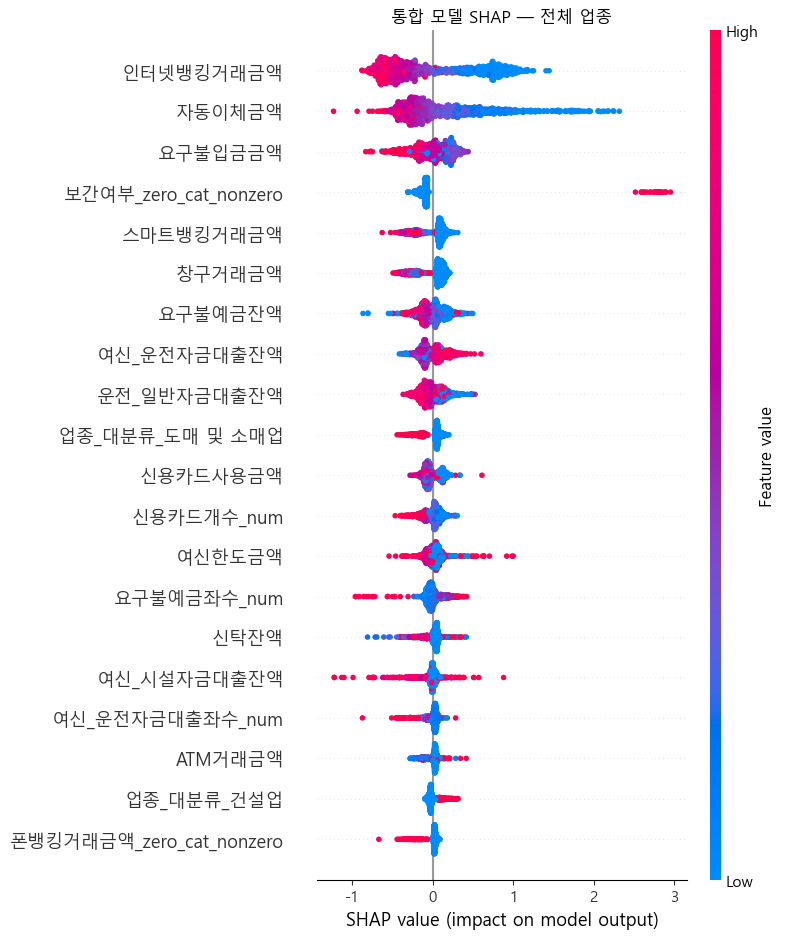

In [30]:
# ============================================================
# SHAP / Feature Importance
# ============================================================

# 업종별 Feature Importance Top 20은 SHAP 설치 여부와 무관하게 출력
for ind, info in IND_MODELS.items():
    print(f'\n[{ind}] Feature Importance Top 20')
    display(info['feature_importance'].head(20))

# 통합 모델 SHAP은 shap 패키지가 있을 때만 실행
try:
    import shap

    prep = INT_PIPE.named_steps['prep']
    lgbm = INT_PIPE.named_steps['model']

    sample_n = min(1500, len(df_test))
    Xte_raw = df_test.sample(sample_n, random_state=RANDOM_STATE).copy()
    Xte_int = apply_clip_log(Xte_raw, list(INT_kept), INT_bounds, INT_logset)

    for c in INT_cat:
        Xte_int[c] = Xte_int[c].astype(str).fillna('missing')

    Xte_int = Xte_int[list(INT_kept) + list(INT_cat)]

    Xt_transformed = prep.transform(Xte_int)
    if hasattr(Xt_transformed, 'toarray'):
        Xt = Xt_transformed.toarray()
    else:
        Xt = np.asarray(Xt_transformed)

    ohe = prep.named_transformers_.get('cat') if 'cat' in prep.named_transformers_ else None
    feature_names = (list(ohe.get_feature_names_out(INT_cat)) if ohe is not None else []) + list(INT_kept)

    explainer = shap.TreeExplainer(lgbm)
    shap_values = explainer.shap_values(Xt)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap_values = np.asarray(shap_values)

    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    shap.summary_plot(
        shap_values,
        Xt,
        feature_names=feature_names,
        show=False,
        max_display=20
    )
    plt.title('통합 모델 SHAP — 전체 업종')
    plt.tight_layout()
    plt.show()

    SHAP_INT = {
        'shap': shap_values,
        'X': Xt,
        'names': feature_names
    }

except Exception as e:
    print('SHAP 계산 스킵:', e)
    SHAP_INT = None


## 단계5 — 중요 변수 기반 EDA (y=0 vs y=1, df_model 기준 원본단위)

In [31]:
# 업종별 상위 중요 수치형 변수에 대해 y=0/1 비교 (clip/log 전 원본 dfx 기준)
EDA_ROWS = []
for ind, info in IND_MODELS.items():
    sub = dfx[dfx['업종_대분류']==ind]
    # FI 상위 중 수치형 원본 변수만 (one-hot 더미 제외)
    top_num = [f for f in info['feature_importance']['feature'] if f in NUM_FEAT_ALL][:8]
    print(f'\n[{ind}] 주요 수치형 변수 y=0 vs y=1')
    for f in top_num:
        g0 = sub.loc[sub['y']==0, f]; g1 = sub.loc[sub['y']==1, f]
        row = {'업종':ind,'변수':f,
               'y0_평균':round(g0.mean(),2),'y1_평균':round(g1.mean(),2),
               'y0_중앙':round(g0.median(),2),'y1_중앙':round(g1.median(),2),
               '차이':round(g1.mean()-g0.mean(),2),
               '차이율':round((g1.mean()-g0.mean())/(abs(g0.mean())+1e-9),3)}
        EDA_ROWS.append(row)
    print(pd.DataFrame([r for r in EDA_ROWS if r['업종']==ind]).to_string(index=False))

# high-zero categorical 변수의 y=0/1 비율 차이
print('\n[high-zero zero_cat 변수의 y=1 비율 (nonzero일 때)]')
for c in high_zero_cat_cols[:10]:
    if c in dfx.columns:
        nz = dfx[dfx[c]=='nonzero']
        if len(nz)>0:
            print(f'  {c}: nonzero일 때 y=1 비율 {nz["y"].mean()*100:.1f}% (전체 {dfx["y"].mean()*100:.1f}%)')


[제조업] 주요 수치형 변수 y=0 vs y=1
 업종          변수   y0_평균   y1_평균  y0_중앙  y1_중앙      차이    차이율
제조업      자동이체금액  236.50  114.12   26.0    6.4 -122.38 -0.517
제조업 여신_운전자금대출잔액 1663.25 1253.44  500.0  300.0 -409.80 -0.246
제조업     요구불예금잔액  176.05   92.36   24.0    2.9  -83.70 -0.475
제조업      여신한도금액 1011.20  630.94   73.0    0.0 -380.26 -0.376
제조업        신탁잔액  330.18  264.03    0.0    0.0  -66.15 -0.200
제조업 운전_일반자금대출잔액 1005.62  850.10  400.0  260.0 -155.53 -0.155
제조업 여신_시설자금대출잔액  891.91  669.28    0.0    0.0 -222.62 -0.250
제조업    신용카드사용금액    7.05    4.20    3.6    0.8   -2.85 -0.405

[도매 및 소매업] 주요 수치형 변수 y=0 vs y=1
      업종          변수  y0_평균  y1_평균  y0_중앙  y1_중앙      차이    차이율
도매 및 소매업      자동이체금액 204.06  22.93   18.0   3.40 -181.13 -0.888
도매 및 소매업     요구불예금잔액 117.72  58.14   14.0   1.20  -59.58 -0.506
도매 및 소매업 여신_운전자금대출잔액 671.50 501.73  230.0 150.00 -169.77 -0.253
도매 및 소매업     요구불입금금액 911.05 206.18  230.0  14.00 -704.87 -0.774
도매 및 소매업    신용카드사용금액   6.08   3.43    2.6   0.09   -2.65 -0.436
도매 및 소

## 5-3. 출력물 정리

In [ ]:
# ============================================================
# 출력물 정리
# ============================================================

print('=' * 70)
print('15-1. 데이터 요약')
print('=' * 70)
print('NOTEBOOK_NAME       :', NOTEBOOK_NAME)
print('전체 df shape       :', df.shape)
print('df_model shape      :', df_model.shape)
print('법인ID 수           :', df_model['법인ID'].nunique())
print('기간                :', df['기준년월'].min(), '~', df['기준년월'].max())
print('warm-up 행 수       :', (~df['y_available']).sum())
print('y 분포              :', dict(df_model['y'].value_counts()))

if '보간여부' in df.columns:
    print('보간 생성 row 수    :', int(df['보간여부'].sum()))
    print('보간 포함 법인 수    :', df.loc[df['보간여부'] == 1, '법인ID'].nunique())

print('\n업종별 행 수')
display(dfx['업종_대분류'].value_counts().to_frame('row_count'))

print('\n업종별 법인 수')
display(dfx.groupby('업종_대분류')['법인ID'].nunique().sort_values(ascending=False).to_frame('corp_count'))

print('\n' + '=' * 70)
print('15-2. 0비율 처리 요약')
print('=' * 70)
print('100% 0 제거 변수 수        :', len(zero_100_cols))
print('0비율 85%↑ zero_cat 변수 수:', len(HIGH_ZERO_NUMERIC_DROP_COLS))
print('zero_cat 컬럼              :', high_zero_cat_cols[:50])
print('high-zero 원본 제거 컬럼    :', HIGH_ZERO_NUMERIC_DROP_COLS[:50])

print('\n' + '=' * 70)
print('15-3. 업종별 모델 성능')
print('=' * 70)
display(res_ind)

print('\n' + '=' * 70)
print('15-4. 통합/앙상블 성능')
print('=' * 70)
display(res_ens)

print('\n' + '=' * 70)
print('15-5. 업종별 Top Feature')
print('=' * 70)
for ind, info in IND_MODELS.items():
    print(f'\n[{ind}]')
    display(info['feature_importance'].head(10))

print('\n' + '=' * 70)
print('15-6. EDA 요약')
print('=' * 70)

if EDA_ROWS:
    eda_df = pd.DataFrame(EDA_ROWS).reindex(columns=[
        '업종', '변수',
        'y0_평균', 'y1_평균',
        'y0_중앙', 'y1_중앙',
        '차이', '차이율'
    ])
    display(eda_df)
else:
    eda_df = pd.DataFrame()
    print('EDA_ROWS가 비어 있습니다.')

# 결과 저장
res_ind_path = f'{NOTEBOOK_NAME}_업종별성능.csv'
res_ens_path = f'{NOTEBOOK_NAME}_앙상블성능.csv'
eda_path = f'{NOTEBOOK_NAME}_eda요약.csv'

res_ind.to_csv(res_ind_path, index=False, encoding='utf-8-sig')
res_ens.to_csv(res_ens_path, index=False, encoding='utf-8-sig')
eda_df.to_csv(eda_path, index=False, encoding='utf-8-sig')

# 누락검정 프로필도 참고용 저장
if 'corp_profile' in globals():
    corp_profile.to_csv(f'{NOTEBOOK_NAME}_누락검정프로필.csv', index=False, encoding='utf-8-sig')

print('\n저장 완료:')
print(' -', res_ind_path)
print(' -', res_ens_path)
print(' -', eda_path)
if 'corp_profile' in globals():
    print(' -', f'{NOTEBOOK_NAME}_누락검정프로필.csv')


15-1. 데이터 요약
NOTEBOOK_NAME       : final10
전체 df shape       : (206028, 108)
df_model shape      : (165967, 109)
법인ID 수           : 5723
기간                : 202301 ~ 202512
warm-up 행 수       : 34338
y 분포              : {0: 101695, 1: 64272}
보간 생성 row 수    : 5077
보간 포함 법인 수    : 2351

업종별 행 수


,row_count
업종_대분류,
제조업,56347
도매 및 소매업,32045
건설업,27492
부동산업,14819



업종별 법인 수


,corp_count
업종_대분류,
제조업,1943
도매 및 소매업,1105
건설업,948
부동산업,511



15-2. 0비율 처리 요약
100% 0 제거 변수 수        : 0
0비율 85%↑ zero_cat 변수 수: 35
zero_cat 컬럼              : ['시설_주택자금대출좌수_num_zero_cat', '운전_주택자금대출좌수_num_zero_cat', '시설_주택자금대출잔액_zero_cat', '운전_주택자금대출잔액_zero_cat', '운전_당좌대출잔액_zero_cat', '운전_외상매출채권담보대출잔액_zero_cat', '운전_당좌대출좌수_num_zero_cat', '수익증권잔액_zero_cat', '운전_무역금융잔액_zero_cat', '시설_에너지절약시설대출잔액_zero_cat', '운전_외상매출채권담보대출좌수_num_zero_cat', '시설_에너지절약시설대출좌수_num_zero_cat', '운전_무역금융좌수_num_zero_cat', '수익증권좌수_num_zero_cat', '보간여부_zero_cat', '운전_할인어음잔액_zero_cat', '외환_수출실적금액_zero_cat', '운전_기업구매자금대출잔액_zero_cat', '체크카드사용금액_zero_cat', '지역_결측_여부_zero_cat', '외환_수입실적금액_zero_cat', '운전_기업구매자금대출좌수_num_zero_cat', '운전_할인어음좌수_num_zero_cat', '시설_기타시설자금대출잔액_zero_cat', '적립식예금잔액_zero_cat', '시설_기타시설자금대출좌수_num_zero_cat', '거치식예금잔액_zero_cat', '운전_기타운전자금대출잔액_zero_cat', '운전_기타운전자금대출좌수_num_zero_cat', '적립식예금좌수_num_zero_cat', '거치식예금좌수_num_zero_cat', '폰뱅킹거래금액_zero_cat']
high-zero 원본 제거 컬럼    : ['시설_주택자금대출좌수_num', '운전_주택자금대출좌수_num', '시설_주택자금대출잔액', '운전_주택자금대출잔액', '운전_당좌대출잔액', '운전_외상매출채

...

,feature,importance
75,요구불예금잔액,1597
86,자동이체금액,1432
87,요구불입금금액,1208
80,시설_일반자금대출잔액,1205
88,요구불출금금액,1175
83,인터넷뱅킹거래금액,894
79,여신_운전자금대출잔액,872
84,스마트뱅킹거래금액,685
81,신용카드사용금액,665
78,여신한도금액,470



15-6. EDA 요약


,업종,변수,y0_평균,y1_평균,y0_중앙,y1_중앙,차이,차이율
0,제조업,자동이체금액,236.50,114.12,26.0,6.40,-122.38,-0.517
1,제조업,여신_운전자금대출잔액,1663.25,1253.44,500.0,300.00,-409.80,-0.246
2,제조업,요구불예금잔액,176.05,92.36,24.0,2.90,-83.70,-0.475
3,제조업,여신한도금액,1011.20,630.94,73.0,0.00,-380.26,-0.376
4,제조업,신탁잔액,330.18,264.03,0.0,0.00,-66.15,-0.200
5,제조업,운전_일반자금대출잔액,1005.62,850.10,400.0,260.00,-155.53,-0.155
6,제조업,여신_시설자금대출잔액,891.91,669.28,0.0,0.00,-222.62,-0.250
7,제조업,신용카드사용금액,7.05,4.20,3.6,0.80,-2.85,-0.405
8,도매 및 소매업,자동이체금액,204.06,22.93,18.0,3.40,-181.13,-0.888
9,도매 및 소매업,요구불예금잔액,117.72,58.14,14.0,1.20,-59.58,-0.506


PermissionError: [Errno 13] Permission denied: 'final10_업종별성능.csv'

: 